# 🧠 Stroke Prediction: ML for Cerebrovascular Risk Screening

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting stroke risk from demographic and clinical factors to support preventive health programs  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting stroke risk using patient demographics, comorbidities (hypertension, heart disease, diabetes), lifestyle factors (smoking, BMI), and clinical data. The model supports **population-level stroke risk screening** and **GP-driven preventive intervention**.

### Government Policy Context
- **Department of Health & Aged Care** — National Stroke Strategy, Stroke Foundation partnership
- **AIHW** — Stroke surveillance, burden of disease, hospitalisation analytics
- **Stroke Foundation** — InformMe clinical guidelines, F.A.S.T. awareness campaigns
- **Medicare** — Chronic disease management (items 721/723), GP Management Plans for stroke risk
- **PBS** — Anticoagulant/antiplatelet utilisation, statin prescribing for stroke prevention

### Clinical Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| High stroke risk | Urgent neurology/cardiology referral, imaging | GP + specialist |
| Moderate risk | Aggressive risk factor management (BP, cholesterol, AF) | GP + practice nurse |
| Low risk (confident) | Annual cardiovascular health check | Automated recall |
| Low risk (modifiable factors) | Lifestyle intervention (smoking, diet, exercise) | Practice nurse + allied health |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is None:
    raise FileNotFoundError("No CSV found")

df = pd.read_csv(data_path)
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/fedesoriano/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv

Using: /kaggle/input/datasets/fedesoriano/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv
Loaded: 5,110 rows x 12 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:25s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. id                        | int64      | unique= 5110 | nulls=  0 | eg: 9046
   1. gender                    | object     | unique=    3 | nulls=  0 | eg: Male
   2. age                       | float64    | unique=  104 | nulls=  0 | eg: 67.0
   3. hypertension              | int64      | unique=    2 | nulls=  0 | eg: 0
   4. heart_disease             | int64      | unique=    2 | nulls=  0 | eg: 1
   5. ever_married              | object     | unique=    2 | nulls=  0 | eg: Yes
   6. work_type                 | object     | unique=    5 | nulls=  0 | eg: Private
   7. Residence_type            | object     | unique=    2 | nulls=  0 | eg: Urban
   8. avg_glucose_level         | float64    | unique= 3979 | nulls=  0 | eg: 228.69
   9. bmi                       | float64    | unique=  418 | nulls=201 | eg: 36.6
  10. smoking_status            | object     | unique=    4 | nulls=  0 | eg: formerly smoked
  11. stroke                    | int64      | unique=    2 | 

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Target Variable Analysis

In [4]:
# Known target for stroke dataset
target_candidates = ['stroke', 'Stroke', 'target', 'Target', 'class', 'Class', 'label', 'outcome']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

if df[target_col].dtype == 'object':
    yes_kw = ['Yes', 'yes', 'Y', '1', 'Stroke']
    mapping = {v: (1 if v in yes_kw else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped: {mapping}")

df[target_col] = df[target_col].astype(int)
print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
print(f"\nProportions:")
print(df[target_col].value_counts(normalize=True).sort_index().round(4))
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'stroke'

Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Proportions:
stroke
0    0.9513
1    0.0487
Name: proportion, dtype: float64

Imbalance ratio: 0.051


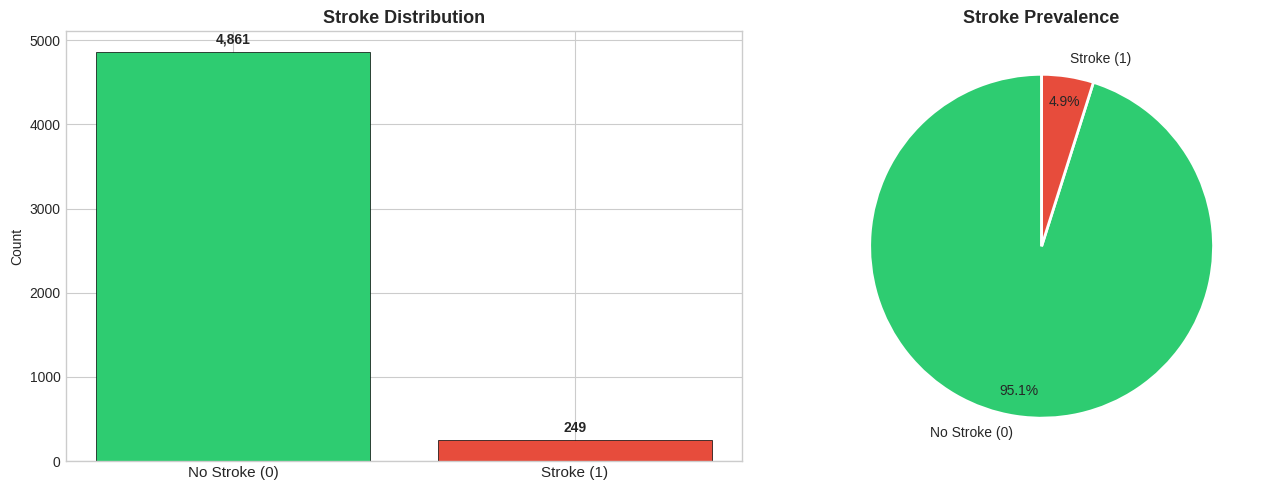

AU context: ~27,400 strokes per year in Australia (Stroke Foundation).
Stroke is a leading cause of disability. 80% of strokes are preventable.
F.A.S.T. campaign: Face drooping, Arm weakness, Speech difficulty, Time to call 000.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = ['No Stroke (0)', 'Stroke (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(range(2), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(2)); axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Stroke Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, f'{v:,}', ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Stroke Prevalence', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: ~27,400 strokes per year in Australia (Stroke Foundation).")
print("Stroke is a leading cause of disability. 80% of strokes are preventable.")
print("F.A.S.T. campaign: Face drooping, Arm weakness, Speech difficulty, Time to call 000.")


## 3. Exploratory Data Analysis

Key clinical questions:
- Which risk factors (hypertension, heart disease, diabetes) most predict stroke?
- How do age and BMI interact with stroke risk?
- Does smoking status correlate with stroke incidence?
- Are there gender differences in stroke prevalence?


Numeric features (5): ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']


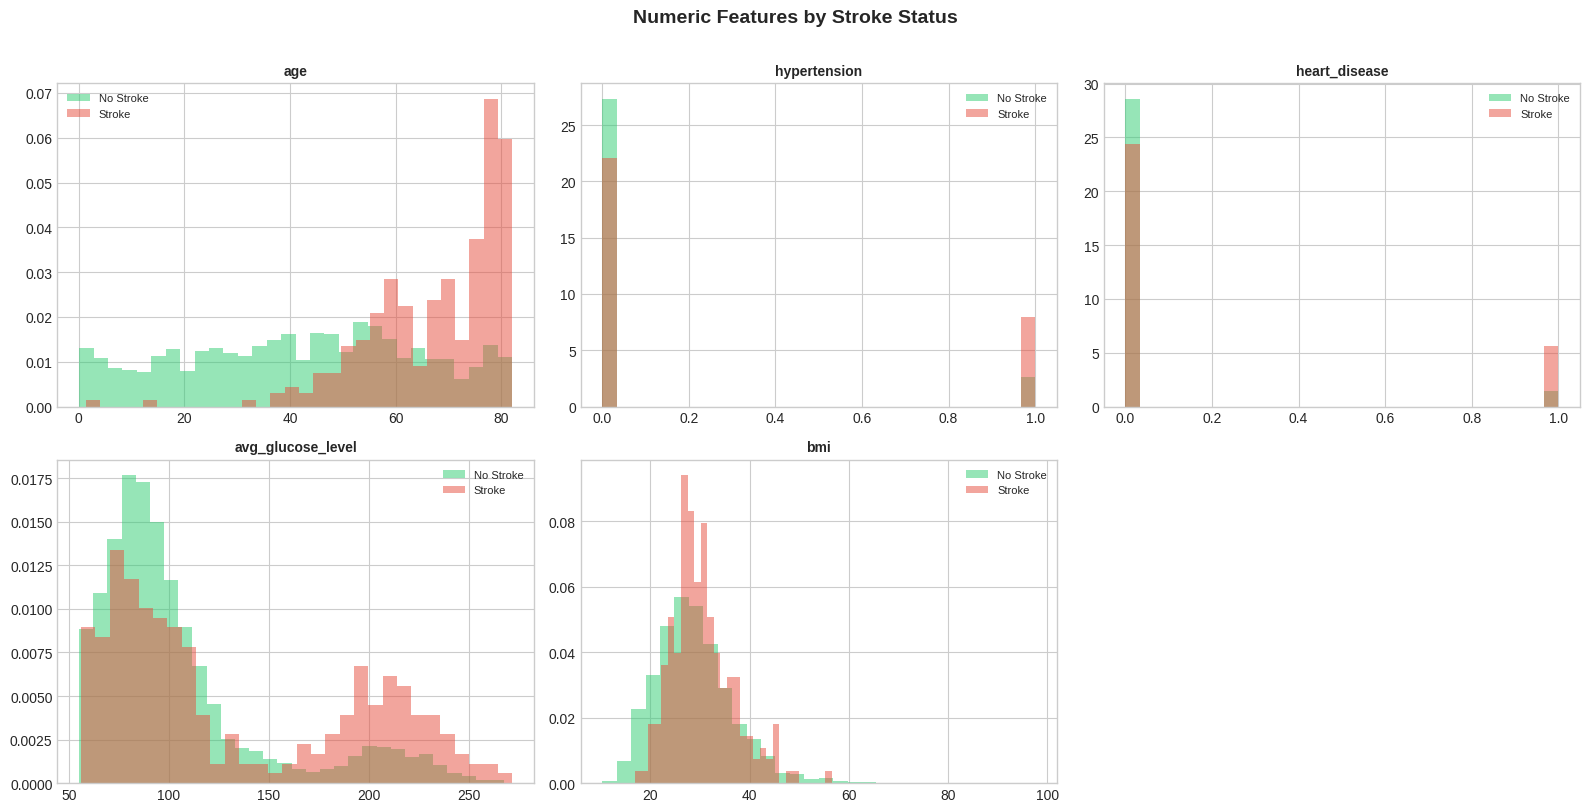

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['id', 'index']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

plot_cols = numeric_cols[:6]
if len(plot_cols) > 0:
    n_rows_p = (len(plot_cols) + 2) // 3
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['No Stroke', 'Stroke']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=30, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=10, fontweight='bold'); axes[i].legend(fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Numeric Features by Stroke Status', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


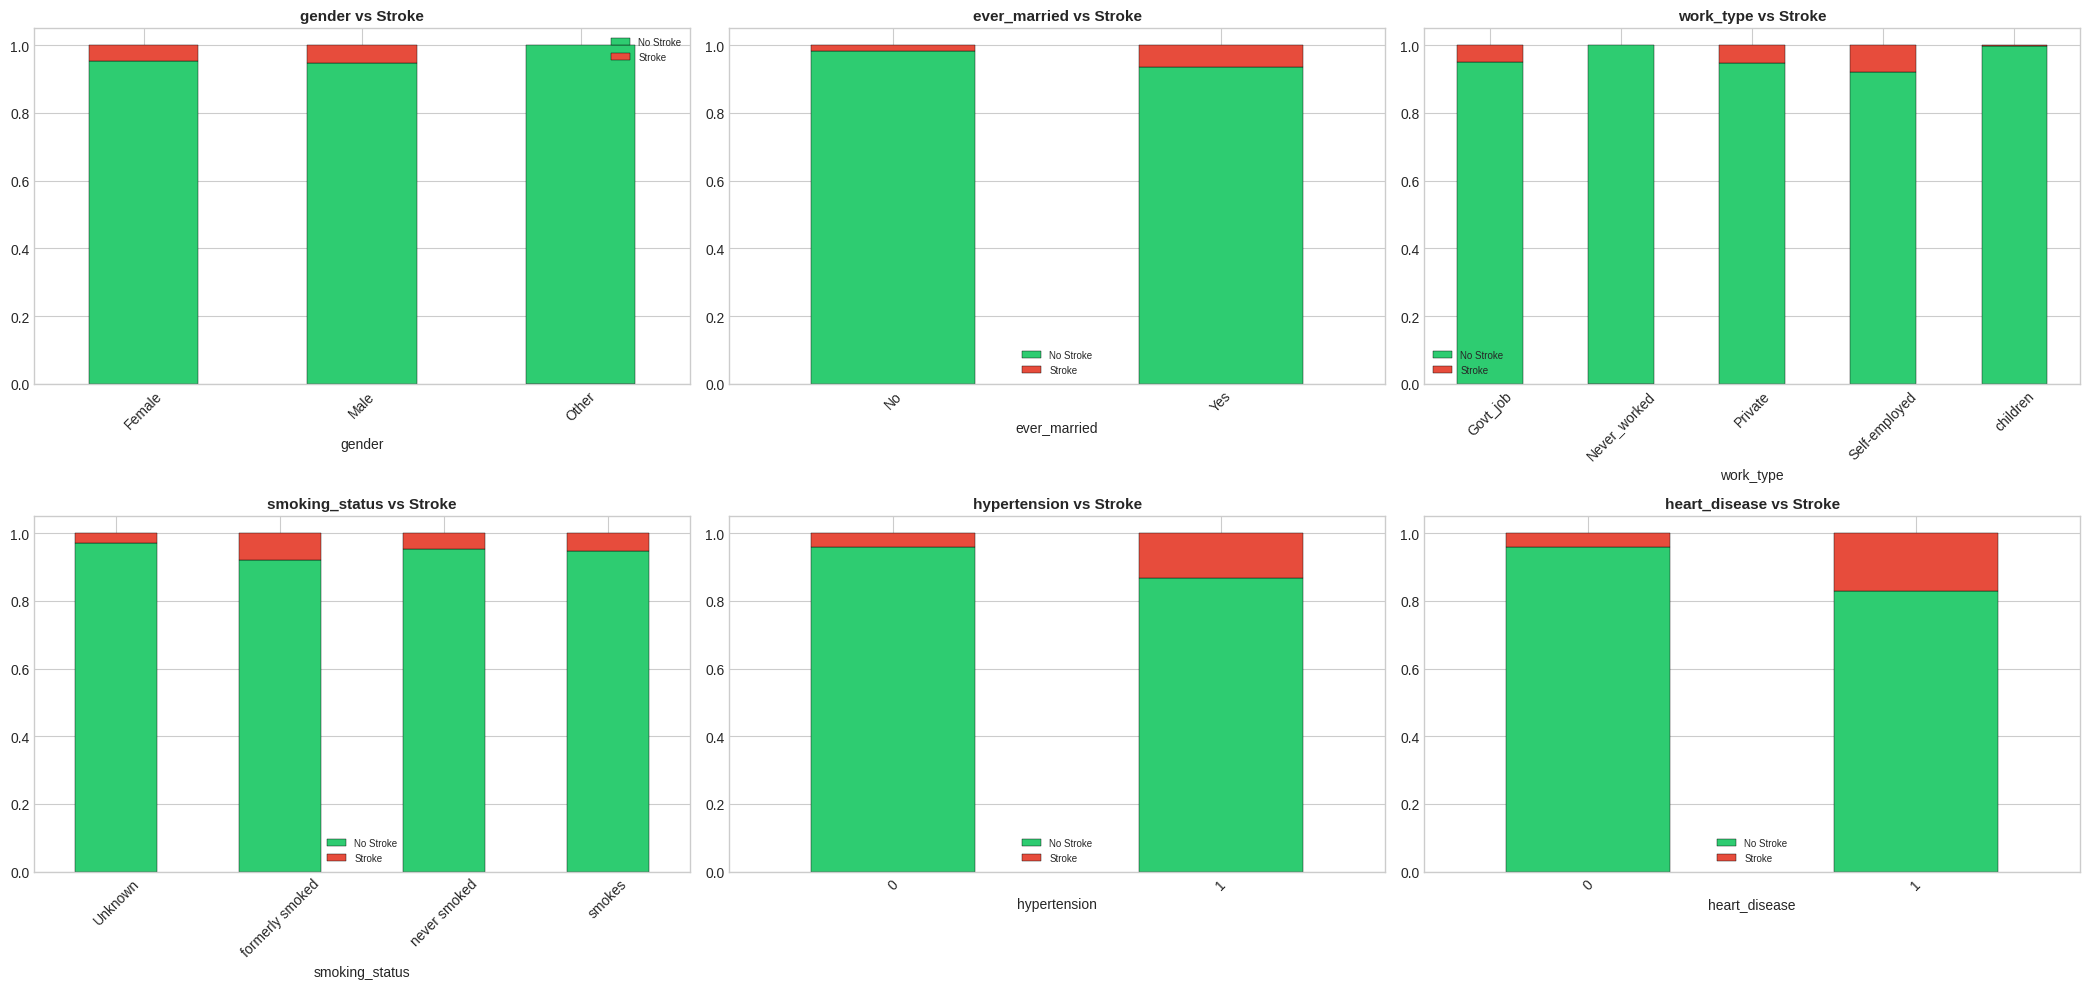

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 10 and 'id' not in c.lower()]
# Also include binary numeric as categorical
binary_num = [c for c in numeric_cols if df[c].nunique() <= 3]
plot_cats = cat_cols + binary_num
plot_cats = plot_cats[:6]

if len(plot_cats) > 0:
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = (len(plot_cats) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'],
                edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Stroke', fontsize=11, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(['No Stroke', 'Stroke'], fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


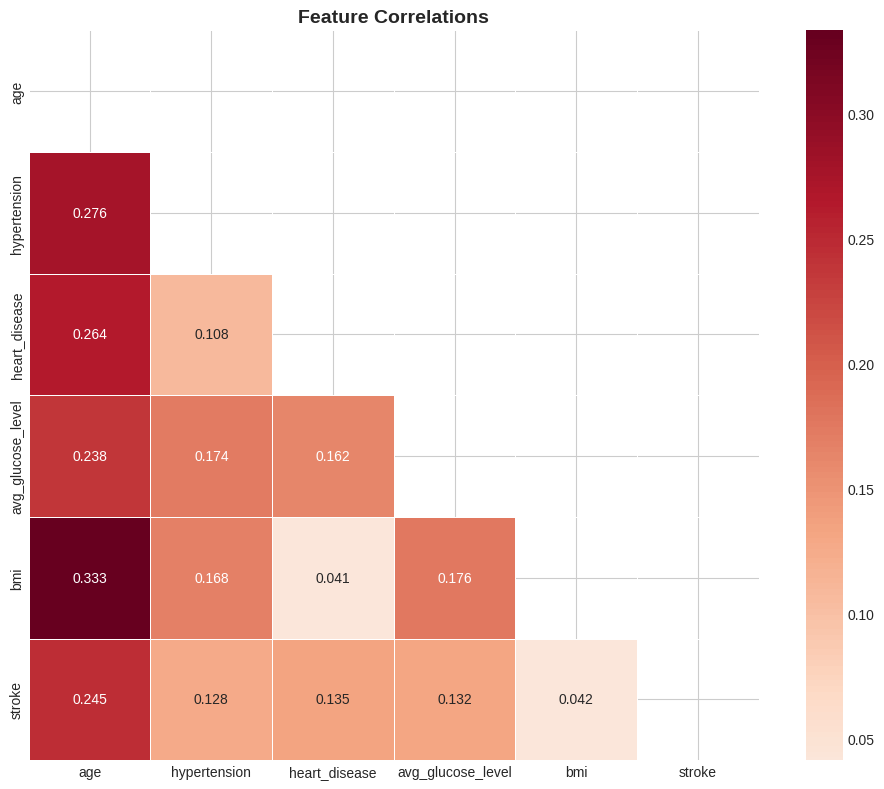

Correlations with stroke:
  age                       +0.2453
  heart_disease             +0.1349
  avg_glucose_level         +0.1319
  hypertension              +0.1279
  bmi                       +0.0424


In [8]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols + [target_col]].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Correlations with stroke:")
    for feat, val in target_corr.items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:25s} {direction}{val:.4f}")


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()

# Drop ID column
drop_cols = [c for c in df_model.columns if c.lower() in ['id', 'index', 'unnamed: 0']]
if drop_cols:
    df_model.drop(columns=drop_cols, inplace=True)
    print(f"Dropped: {drop_cols}")

# Handle 'bmi' column — may have 'N/A' string
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = df_model[col].replace('N/A', np.nan)
        df_model[col] = df_model[col].replace('Unknown', np.nan)

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes -> {list(le.classes_)[:5]}")

# Convert bmi to numeric if needed
if 'bmi' in df_model.columns:
    df_model['bmi'] = pd.to_numeric(df_model['bmi'], errors='coerce')

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

if X.isnull().sum().sum() > 0:
    print(f"\nImputing {X.isnull().sum().sum()} missing values...")
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")
print(f"Target: {dict(zip(*np.unique(y, return_counts=True)))}")


Dropped: ['id']
  Encoded 'gender': 3 classes -> ['Female', 'Male', 'Other']
  Encoded 'ever_married': 2 classes -> ['No', 'Yes']
  Encoded 'work_type': 5 classes -> ['Govt_job', 'Never_worked', 'Private', 'Self-employed', 'children']
  Encoded 'Residence_type': 2 classes -> ['Rural', 'Urban']
  Encoded 'smoking_status': 4 classes -> ['__MISSING__', 'formerly smoked', 'never smoked', 'smokes']

Imputing 201 missing values...

Feature matrix: (5110, 10)
Target: {np.int64(0): np.int64(4861), np.int64(1): np.int64(249)}


In [10]:
feature_names = X.columns.tolist()
composites_added = []

# Age risk categories
if 'age' in feature_names:
    X['age_over_65'] = (X['age'] >= 65).astype(int)
    composites_added.append('age_over_65')
    print("Created 'age_over_65'")

# BMI risk categories
if 'bmi' in feature_names:
    X['bmi_obese'] = (X['bmi'] >= 30).astype(int)
    composites_added.append('bmi_obese')
    print("Created 'bmi_obese' (BMI >= 30)")

# Multi-risk factor count
risk_cols = []
if 'hypertension' in feature_names: risk_cols.append('hypertension')
if 'heart_disease' in feature_names: risk_cols.append('heart_disease')
if 'age_over_65' in X.columns: risk_cols.append('age_over_65')
if 'bmi_obese' in X.columns: risk_cols.append('bmi_obese')
if len(risk_cols) >= 2:
    X['stroke_risk_count'] = X[risk_cols].sum(axis=1)
    composites_added.append('stroke_risk_count')
    print(f"Created 'stroke_risk_count' from {risk_cols}")

# Age-glucose interaction
if 'age' in feature_names and 'avg_glucose_level' in feature_names:
    X['age_glucose_risk'] = X['age'] * X['avg_glucose_level'] / 100
    composites_added.append('age_glucose_risk')
    print("Created 'age_glucose_risk'")

print(f"\nTotal engineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'age_over_65'
Created 'bmi_obese' (BMI >= 30)
Created 'stroke_risk_count' from ['hypertension', 'heart_disease', 'age_over_65', 'bmi_obese']
Created 'age_glucose_risk'

Total engineered: 4
Final feature count: 14


## 5. Model Training & Cross-Validation

In [11]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.9513  F1=0.0000  AUC=0.8422
  Fold 2: Acc=0.9513  F1=0.0000  AUC=0.8417
  Fold 3: Acc=0.9513  F1=0.0235  AUC=0.8311
  -- Acc: 0.9513  F1: 0.0078  AUC: 0.8383  Time: 0.46s

Training: Random Forest
  Fold 1: Acc=0.9495  F1=0.0000  AUC=0.7947
  Fold 2: Acc=0.9507  F1=0.0233  AUC=0.8117
  Fold 3: Acc=0.9483  F1=0.0222  AUC=0.7988
  -- Acc: 0.9495  F1: 0.0152  AUC: 0.8017  Time: 1.11s

Training: XGBoost
  Fold 1: Acc=0.9437  F1=0.0400  AUC=0.7997
  Fold 2: Acc=0.9419  F1=0.0198  AUC=0.7757
  Fold 3: Acc=0.9454  F1=0.1468  AUC=0.8059
  -- Acc: 0.9436  F1: 0.0689  AUC: 0.7938  Time: 0.32s

Training: LightGBM
  Fold 1: Acc=0.9437  F1=0.0588  AUC=0.8283
  Fold 2: Acc=0.9472  F1=0.0625  AUC=0.7958
  Fold 3: Acc=0.9448  F1=0.1296  AUC=0.8176
  -- Acc: 0.9452  F1: 0.0837  AUC: 0.8139  Time: 0.38s


## 6. Model Comparison & Selection

In [13]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier  Time
Logistic Regression 0.9513 +/- 0.0000 0.0078 +/- 0.0111 0.8383 +/- 0.0051 0.0427 0.46s
           LightGBM 0.9452 +/- 0.0015 0.0837 +/- 0.0325 0.8139 +/- 0.0135 0.0478 0.38s
      Random Forest 0.9495 +/- 0.0010 0.0152 +/- 0.0107 0.8017 +/- 0.0072 0.0454 1.11s
            XGBoost 0.9436 +/- 0.0014 0.0689 +/- 0.0557 0.7938 +/- 0.0130 0.0500 0.32s

Best model: Logistic Regression


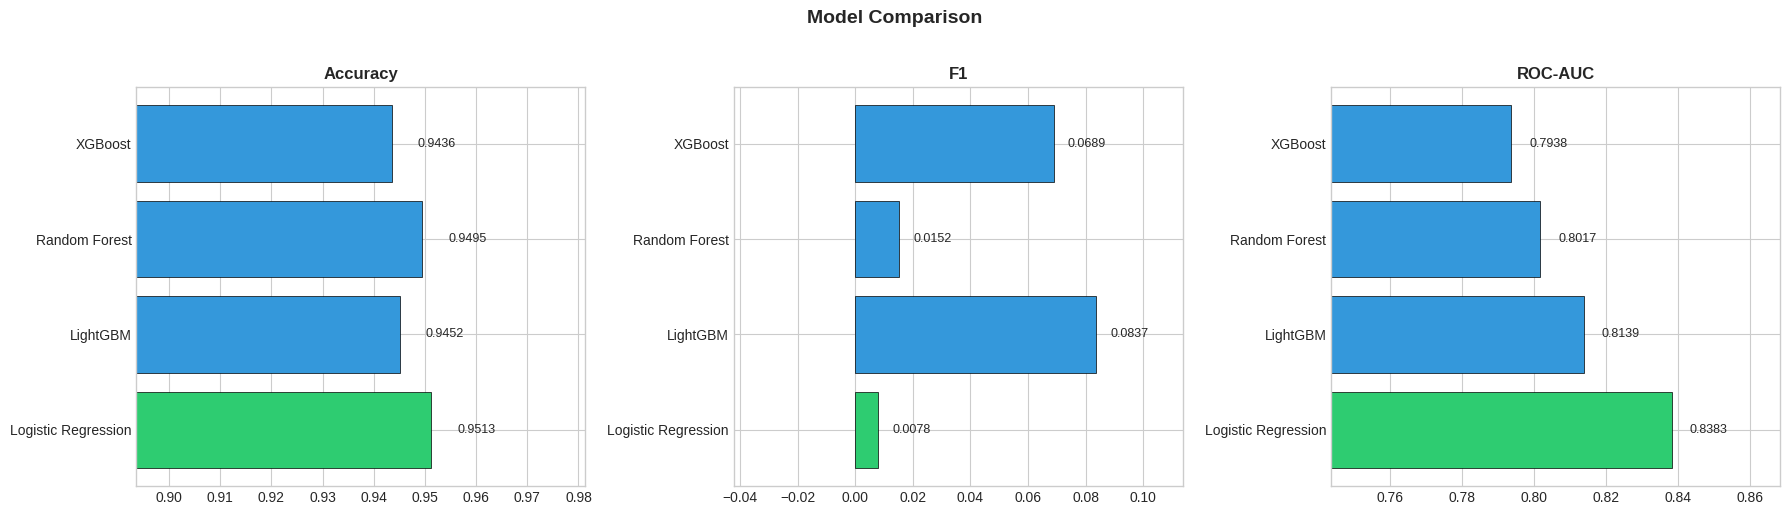

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

For stroke screening:
- **False negatives** (missed stroke risk) = potential stroke, disability, death
- **False positives** (false alarm) = unnecessary specialist referral — but clinically preferable
- Screening should bias toward catching all at-risk patients


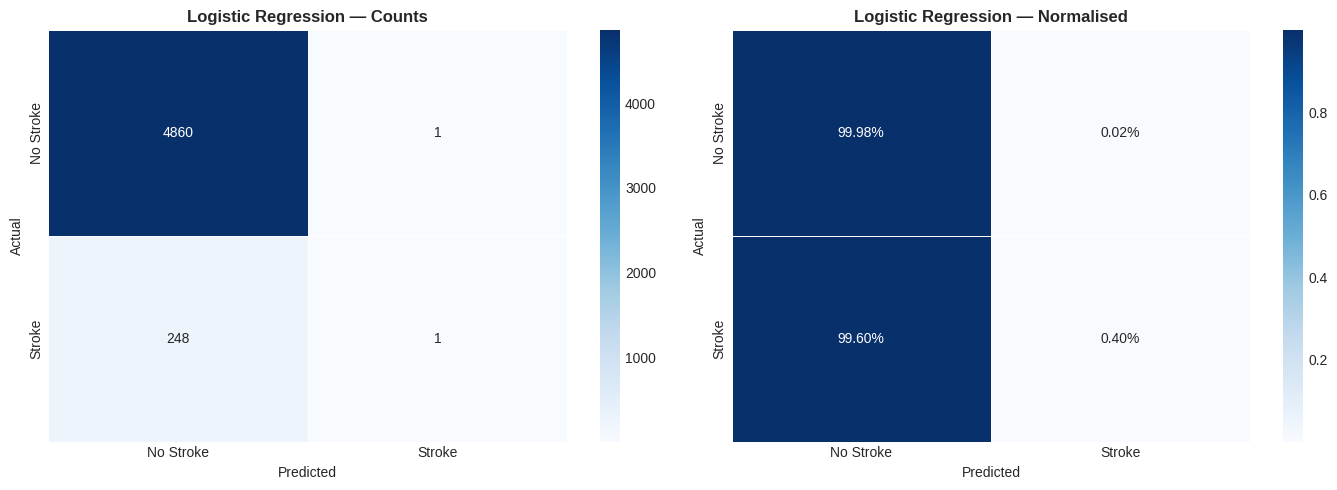


              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.98      4861
      Stroke       0.50      0.00      0.01       249

    accuracy                           0.95      5110
   macro avg       0.73      0.50      0.49      5110
weighted avg       0.93      0.95      0.93      5110



In [15]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['No Stroke', 'Stroke']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


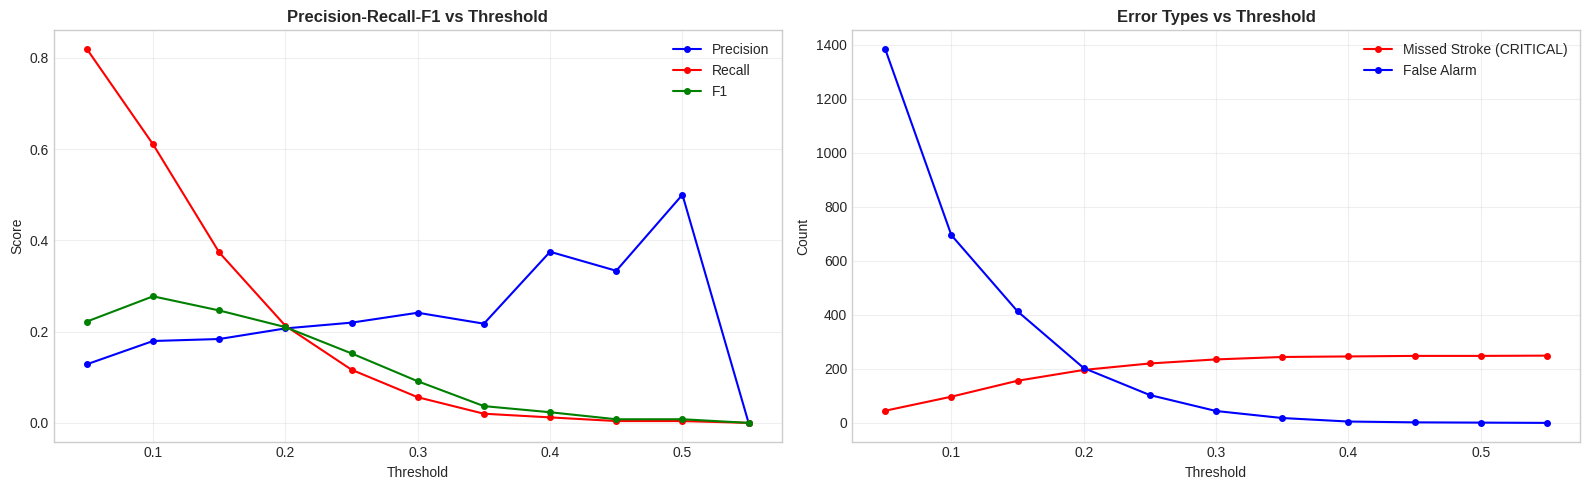


Optimal threshold (F1): 0.10
Note: Stroke is heavily imbalanced (~5% prevalence). Low threshold recommended for screening.


In [16]:
thresholds = np.arange(0.05, 0.60, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed Stroke (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Alarm (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Stroke (FN)'], 'r-o', ms=4, label='Missed Stroke (CRITICAL)')
axes[1].plot(thresh_df['Threshold'], thresh_df['False Alarm (FP)'], 'b-o', ms=4, label='False Alarm')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")
print(f"Note: Stroke is heavily imbalanced (~5% prevalence). Low threshold recommended for screening.")


## 8. Feature Importance & Policy Insights

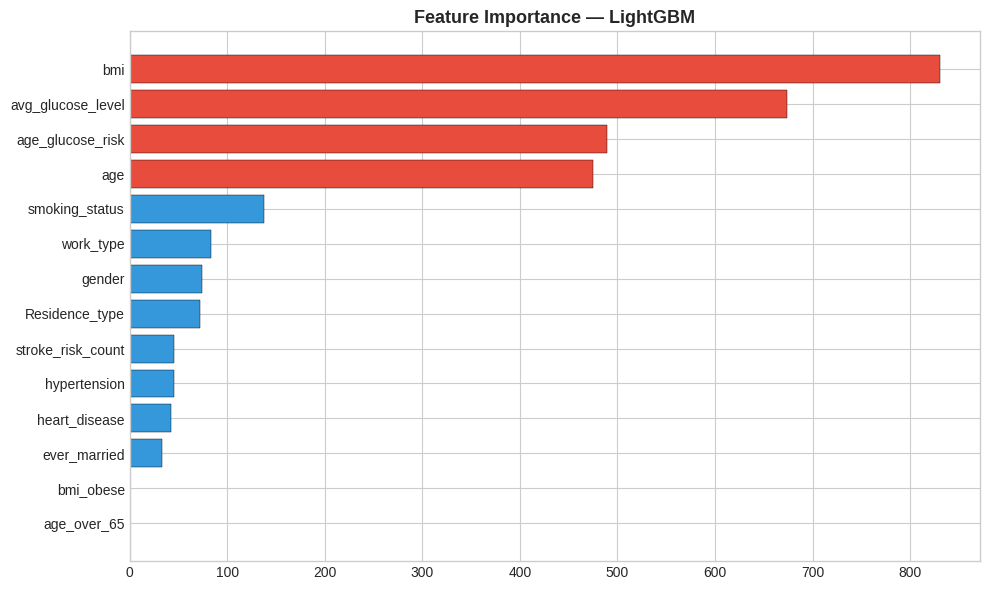

TOP 5 STROKE RISK PREDICTORS
  bmi                        830.0000
  avg_glucose_level          674.0000
  age_glucose_risk           489.0000
  age                        475.0000
  smoking_status             138.0000


In [17]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 STROKE RISK PREDICTORS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")


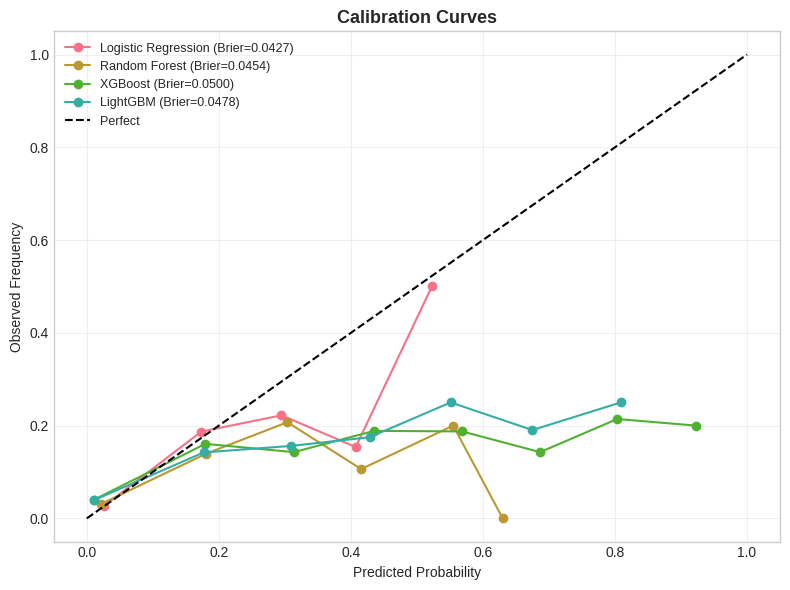

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [19]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.70': best_res['auc_mean'] > 0.70,
    'F1 > 0.15': best_res['f1_mean'] > 0.15,
    'Brier < 0.10': best_res['brier_mean'] < 0.10,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Logistic Regression
  ROC-AUC:              0.8383
  F1:                   0.0078
  Precision:            0.1667
  Recall:               0.0040
  Brier Score:          0.0427
  Training time:        0.5s
  Feature count:        14
  Dataset rows:         5,110
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.10

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.70
  [FAIL] F1 > 0.15
  [pass] Brier < 0.10
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  SOME CHECKS FAILED


In [20]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: GP clinical systems, My Health Record, hospital discharge data
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (vitals, pathology, comorbidities)
   Schedule: Real-time at GP consultation + quarterly population screening

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) embedded in GP clinical software
   Output: Stroke risk score + modifiable risk factors + action plan
   Batch: Quarterly PHN stroke risk stratification by LGA

3. INTEGRATION POINTS
   GP desktop: Stroke risk alert in Best Practice / Medical Director
   Medicare: Trigger Health Assessment items for high-risk patients
   Stroke Foundation: F.A.S.T. campaign targeting high-risk areas
   Ambulance services: Pre-hospital stroke risk data for triage
   Rehabilitation: Post-stroke outcome prediction for rehab planning

4. CLINICAL GOVERNANCE
   TGA: Software as Medical Device classification
   Validation: Prospective study against stroke outcomes (12-month)
   Explainability: Modifiable risk factors highlighted for patient
   Equity: Monitor Indigenous, CALD, rural/remote populations
   Stroke Foundation: Alignment with InformMe clinical guidelines

5. MONITORING & RETRAINING
   Drift: PSI on clinical features quarterly
   Performance: AUC on confirmed stroke events (12-month lag)
   Retraining: Annual with confirmed stroke outcomes
   Guidelines: Recalibrate when Stroke Foundation guidelines update
   Population aging: Adjust for demographic shifts

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: GP clinical systems, My Health Record, hospital discharge data
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (vitals, pathology, comorbidities)
   Schedule: Real-time at GP consultation + quarterly population screening

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) embedded in GP clinical software
   Output: Stroke risk score + modifiable risk factors + action plan
   Batch: Quarterly PHN stroke risk stratification by LGA

3. INTEGRATION POINTS
   GP desktop: Stroke risk alert in Best Practice / Medical Director
   Medicare: Trigger Health Assessment items for high-risk patients
   Stroke Foundation: F.A.S.T. campaign targeting high-risk areas
   Ambulance services: Pre-hospital stroke risk data for triage
   Rehabilitation: Post-stroke outcome prediction for rehab planning

4. CLINICAL GOVERNANCE
   TGA: Software as Medical